# 24RB1003 松澤颯斗

# 演習：LLE のスクラッチ実装

### 課題1：`make_swiss_roll` データに対して LLE をスクラッチ実装する

`sklearn.datasets.make_swiss_roll`（$m=1000$, `noise=0.05`）でデータを作成し，以下を行う．

1. 各点の $k$ 近傍を求める（ここでは $k=10$）．  
2. 各点について局所グラム行列 $C$ を作り，重み $w$ を計算して $W$ を構成する．  
3. $M=(I-W)^\top(I-W)$ を固有値分解し，小さい方から 2, 3 番目の固有ベクトルで 2 次元埋め込みを作る．  
4. 元の 3 次元データと埋め込み結果を，`make_swiss_roll` の返り値 $t$ で色付けしてプロットする．  
5. `sklearn.manifold.LocallyLinearEmbedding` の結果と比較する．


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_swiss_roll
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import LocallyLinearEmbedding

import warnings
warnings.filterwarnings("ignore")


### Swiss roll データを作成する

In [2]:
# データ数，ノイズ，近傍数を設定する
n_samples = 1000
noise = 0.05
k = 10
n_components = 2

# Swiss roll データを生成する
X, t = make_swiss_roll(n_samples=n_samples, noise=noise, random_state=0)

# データの形状を確認する
print("X shape:", X.shape)
print("t shape:", t.shape)


X shape: (1000, 3)
t shape: (1000,)


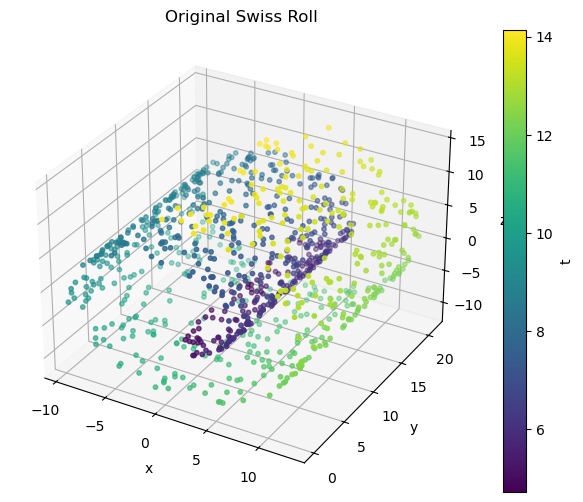

In [3]:
# 元の3次元データを確認する
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap="viridis", s=10)
ax.set_title("Original Swiss Roll")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
fig.colorbar(scatter, ax=ax, label="t")
plt.show()


### 1. 各点の $k$ 近傍を求める

In [4]:
# NearestNeighbors を用いて各点の近傍を求める
# 自分自身も最近傍として含まれるため，k+1 個を取り，あとで自分自身を除く
nn = NearestNeighbors(n_neighbors=k + 1)
nn.fit(X)

distances, indices = nn.kneighbors(X)

# 0列目は自分自身なので除外する
neighbor_indices = indices[:, 1:]
neighbor_distances = distances[:, 1:]

print("neighbor_indices shape:", neighbor_indices.shape)
print("neighbor_distances shape:", neighbor_distances.shape)


neighbor_indices shape: (1000, 10)
neighbor_distances shape: (1000, 10)


In [5]:
# 0番目の点の近傍を確認する
print("0番目の点の近傍インデックス:")
print(neighbor_indices[0])

print("\n0番目の点から近傍点までの距離:")
print(neighbor_distances[0])


0番目の点の近傍インデックス:
[520 354 246 134   3 983 186 921 436 893]

0番目の点から近傍点までの距離:
[1.21735804 1.23341145 1.62950685 2.26592275 2.44685126 2.64347727
 2.65412987 2.80297779 2.84368037 2.95599377]


### 2. 局所グラム行列 $C$ から重み $w$ を求め，$W$ を構成する

各点 $x_i$ に対して，近傍点 $x_j$ の重み付き平均で再構成することを考える．

$$
x_i \approx \sum_{j \in N(i)} w_{ij}x_j, \quad \sum_{j \in N(i)} w_{ij}=1
$$

局所グラム行列を

$$
C_{jl}=(x_i-x_j)^\top(x_i-x_l)
$$

とすると，重みは次の閉形式で求められる．

$$
w = \frac{C^{-1}\mathbf{1}}{\mathbf{1}^\top C^{-1}\mathbf{1}}
$$

ただし，数値安定化のために $C \leftarrow C + 10^{-3}\mathrm{tr}(C)I$ とする．


In [6]:
def compute_lle_weight_matrix(X, neighbor_indices, reg=1e-3):
    """LLE の重み行列 W をスクラッチで計算する関数"""
    n_samples = X.shape[0]
    k = neighbor_indices.shape[1]

    W = np.zeros((n_samples, n_samples))
    ones = np.ones(k)

    for i in range(n_samples):
        neighbors = neighbor_indices[i]

        # 近傍点との差分行列を作る
        Z = X[neighbors] - X[i]

        # 局所グラム行列 C を作る
        C = Z @ Z.T

        # 数値安定化
        trace_C = np.trace(C)
        if trace_C > 0:
            C = C + reg * trace_C * np.eye(k)
        else:
            C = C + reg * np.eye(k)

        # C w = 1 を解き，和が1になるように正規化する
        w = np.linalg.solve(C, ones)
        w = w / np.sum(w)

        # 重み行列 W に格納する
        W[i, neighbors] = w

    return W


W = compute_lle_weight_matrix(X, neighbor_indices, reg=1e-3)

print("W shape:", W.shape)
print("各行の重みの和の最大誤差:", np.max(np.abs(W.sum(axis=1) - 1)))
print("W の非ゼロ要素数:", np.count_nonzero(W))


W shape: (1000, 1000)
各行の重みの和の最大誤差: 4.440892098500626e-16
W の非ゼロ要素数: 10000


In [7]:
# 0番目の点に対する重みを確認する
nonzero_indices = np.nonzero(W[0])[0]

print("0番目の点の近傍インデックス:")
print(nonzero_indices)

print("\n0番目の点に対する重み:")
print(W[0, nonzero_indices])

print("\n重みの和:")
print(W[0, nonzero_indices].sum())


0番目の点の近傍インデックス:
[  3 134 186 246 354 436 520 893 921 983]

0番目の点に対する重み:
[ 0.09806494  0.01029144  0.13218174  0.11479705  0.16407343  0.27645773
  0.17310392 -0.00303995 -0.02593233  0.06000203]

重みの和:
1.0000000000000002


### 3. $M=(I-W)^\top(I-W)$ を固有値分解し，2次元埋め込みを作る

LLE では，求めた重み $W$ を固定して，低次元座標 $Y$ でも同じ局所線形関係が成り立つようにする．

$$
\min_Y \sum_i \left\| y_i - \sum_j w_{ij}y_j \right\|^2
$$

これは

$$
M=(I-W)^\top(I-W)
$$

の固有値問題になる．最小固有値に対応する固有ベクトルは定数ベクトルなので除外し，2次元埋め込みでは小さい方から 2 番目，3 番目の固有ベクトルを使う．


In [8]:
# M を作成する
I = np.eye(n_samples)
M = (I - W).T @ (I - W)

# 数値誤差を避けるために対称化しておく
M = (M + M.T) / 2

# 固有値分解する
eigvals, eigvecs = np.linalg.eigh(M)

# 固有値は小さい順に並んでいる
print("小さい方から6個の固有値:")
print(eigvals[:6])

# 最初の固有ベクトルは定数ベクトルに対応するので除外する
Y_lle_scratch = eigvecs[:, 1:3]

# 制約 ||y||^2 = m に合わせるためにスケールする
Y_lle_scratch = np.sqrt(n_samples) * Y_lle_scratch

print("\nY_lle_scratch shape:", Y_lle_scratch.shape)
print("第1固有ベクトルの最大偏差:", np.max(np.abs(eigvecs[:, 0] - eigvecs[:, 0].mean())))


小さい方から6個の固有値:
[1.64425031e-17 1.16611126e-09 7.62963966e-08 1.41037415e-07
 3.18825803e-07 9.60311167e-07]

Y_lle_scratch shape: (1000, 2)
第1固有ベクトルの最大偏差: 4.6671764647454594e-09


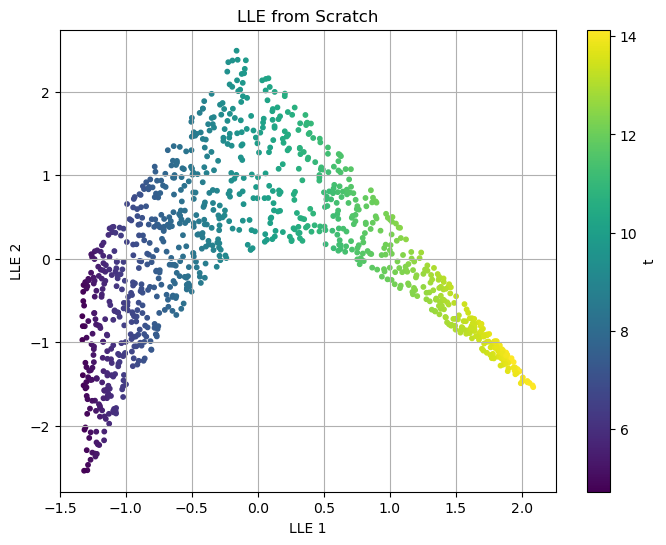

In [9]:
# スクラッチ実装のLLE結果を可視化する
plt.figure(figsize=(8, 6))
scatter = plt.scatter(Y_lle_scratch[:, 0], Y_lle_scratch[:, 1], c=t, cmap="viridis", s=10)
plt.title("LLE from Scratch")
plt.xlabel("LLE 1")
plt.ylabel("LLE 2")
plt.colorbar(scatter, label="t")
plt.grid()
plt.show()


### 4. 元の 3 次元データとスクラッチ実装の埋め込みを並べてプロットする

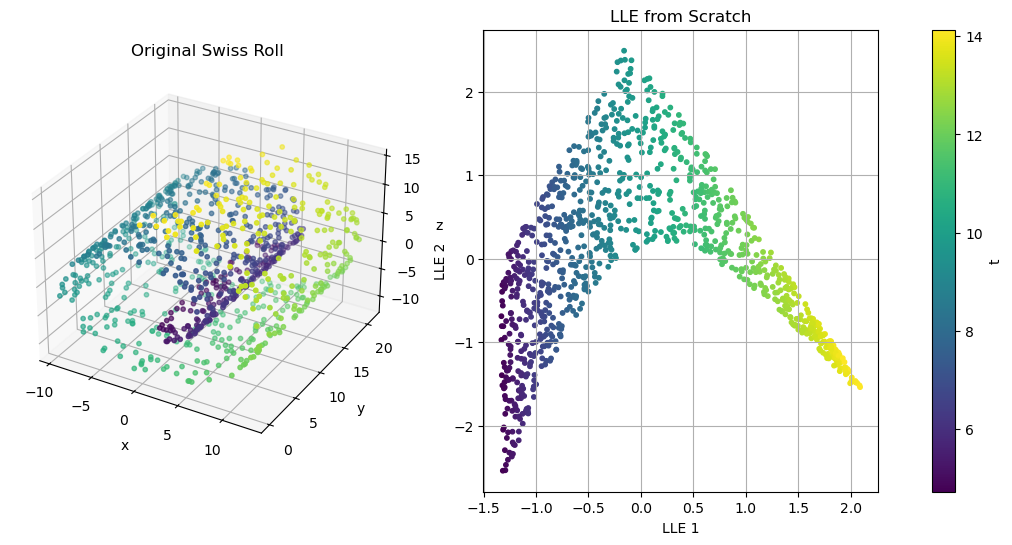

In [10]:
# 元の3次元データとスクラッチ実装の埋め込みを並べて表示する
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
scatter1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap="viridis", s=10)
ax1.set_title("Original Swiss Roll")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2)
scatter2 = ax2.scatter(Y_lle_scratch[:, 0], Y_lle_scratch[:, 1], c=t, cmap="viridis", s=10)
ax2.set_title("LLE from Scratch")
ax2.set_xlabel("LLE 1")
ax2.set_ylabel("LLE 2")
ax2.grid()

fig.colorbar(scatter2, ax=[ax1, ax2], label="t")
plt.show()


### 5. `sklearn.manifold.LocallyLinearEmbedding` の結果と比較する

In [11]:
# sklearn の LLE を実行する
lle = LocallyLinearEmbedding(
    n_neighbors=k,
    n_components=n_components,
    method="standard",
    eigen_solver="auto"
)

Y_lle_sklearn = lle.fit_transform(X)

print("Y_lle_sklearn shape:", Y_lle_sklearn.shape)


Y_lle_sklearn shape: (1000, 2)


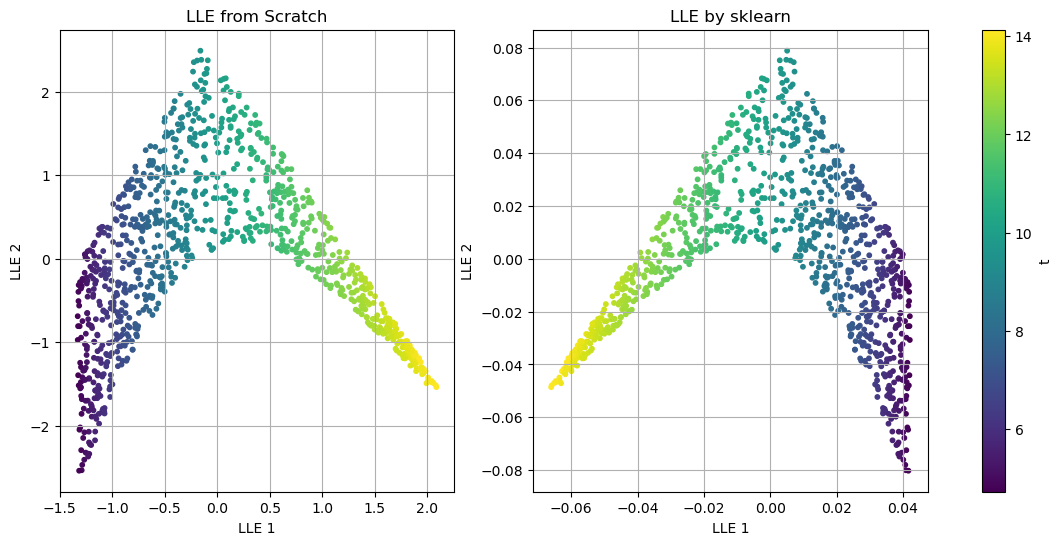

In [12]:
# スクラッチ実装と sklearn 実装の結果を並べて比較する
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = ax1.scatter(Y_lle_scratch[:, 0], Y_lle_scratch[:, 1], c=t, cmap="viridis", s=10)
ax1.set_title("LLE from Scratch")
ax1.set_xlabel("LLE 1")
ax1.set_ylabel("LLE 2")
ax1.grid()

scatter2 = ax2.scatter(Y_lle_sklearn[:, 0], Y_lle_sklearn[:, 1], c=t, cmap="viridis", s=10)
ax2.set_title("LLE by sklearn")
ax2.set_xlabel("LLE 1")
ax2.set_ylabel("LLE 2")
ax2.grid()

fig.colorbar(scatter1, ax=[ax1, ax2], label="t")
plt.show()


# 考察

スクラッチ実装した LLE では，Swiss roll の 3 次元で巻かれた構造を 2 次元平面上に展開するような埋め込みが得られた．  
各点の近傍との線形関係を重み $W$ として保存し，その重みを低次元でも保つように固有値問題を解くことで，非線形な多様体構造を反映した可視化ができたと考えられる．

また，`sklearn.manifold.LocallyLinearEmbedding` の結果と比較すると，点の向きやスケールは完全には一致しないが，これは固有ベクトルの符号や回転・反転に任意性があるためである．  
全体として，$t$ の色の変化が滑らかにつながっており，スクラッチ実装でも sklearn と同様に局所構造を保った埋め込みができていると考えられる．


# AI使用について

Gemini Guided Learningを使用して，LLE の一連の実装方法について質問した．基本的には AI に直接コードを生成させるのではなく，実装の方針や考え方に関するヒントを得て，それをもとに自身でコードを作成した．ただし，ステップ2の重みの正規化や重み行列 $W$ の構成については理解が不十分であったため，AI にコード例を生成させ，その内容を確認しながら理解に努めた．なお，プロットなどの実際のコーディング作業においては，GitHub Copilotの自動補完を補助的に活用してコードを生成した．